In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [8]:
np.random.seed(42)
num_samples=500

years_of_experience=np.random.randint(2,21,size=num_samples)

slope= (200000-60000)/18 # = 7.777
intercept=60000

salary=slope*years_of_experience +intercept +np.random.normal(0,10000,size=num_samples)

data={'Years_of_experience':years_of_experience, 'Salary':salary}
df=pd.DataFrame(data=data)
df.head(5)

,Years_of_experience,Salary
0,8,115037.780010
1,16,182309.972927
2,12,156442.408989
3,9,144753.562169
4,8,130798.818454


In [9]:
df.describe()

,Years_of_experience,Salary
count,500.000000,500.000000
mean,10.616000,142570.011096
std,5.662922,44935.263058
min,2.000000,54881.134555
25%,5.750000,104426.300731
50%,10.000000,139865.032545
75%,16.000000,182341.125962
max,20.000000,241879.376204


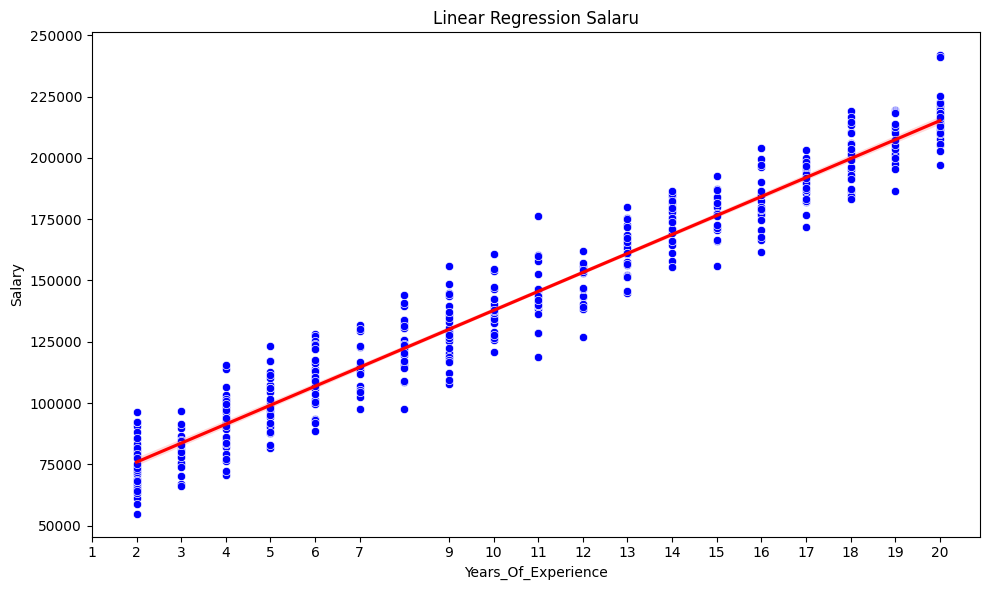

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='Years_of_experience', y='Salary',data=df, color='blue')
sns.regplot(x='Years_of_experience',y='Salary',data=df,scatter=False,color='red')

plt.xlabel("Years_Of_Experience")
plt.xticks([1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,19,20])
plt.ylabel('Salary')
plt.title('Linear Regression Salary')
plt.tight_layout()
plt.show()

In [18]:
X=df[['Years_of_experience']]
y=df['Salary']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=18)

In [19]:
lr= LinearRegression()

In [20]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
lr.score(X_train,y_train)

0.9527314094246802

In [27]:
lr.score(X_test,y_test)

0.9423988014421193

In [ ]:
y_test.reset_index()

,index,Salary
0,207,195881.230339
1,239,67057.111861
2,1,182309.972927
3,103,116218.089872
4,177,88617.845660
...,...,...
95,143,129243.885833
96,355,77026.498147
97,216,103123.250333
98,18,202240.924818


In [32]:
y_pred=lr.predict(X_test)


In [36]:
y_pred=pd.DataFrame(y_pred).reset_index()
y_pred

,level_0,index,0
0,0,0,199799.017119
1,1,1,76057.305215
2,2,2,184331.303131
3,3,3,106992.733191
4,4,4,106992.733191
...,...,...,...
95,95,95,114726.590185
96,96,96,91525.019203
97,97,97,91525.019203
98,98,98,199799.017119


In [37]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [38]:
y_pred=lr.predict(X_test)

In [39]:
mean_absolute_error(y_test,y_pred)

8342.733503560728

In [40]:
mean_squared_error(y_test,y_pred)

114604302.39217418

In [41]:
r2_score(y_test,y_pred)

0.9423988014421193

In [42]:
lr.coef_

array([7733.856994])

In [43]:
lr.intercept_

np.float64(60589.59122676765)

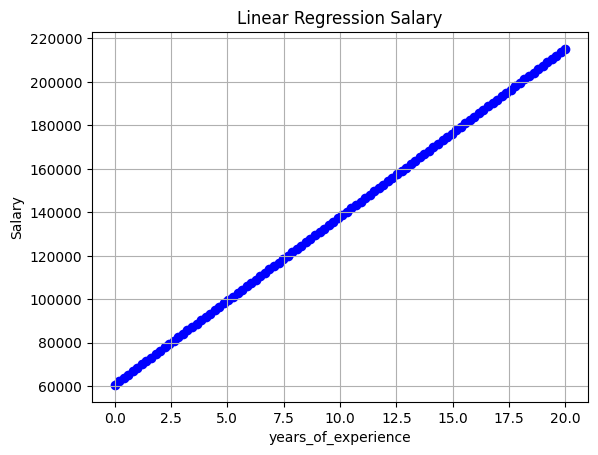

In [48]:
coeffiecients=lr.coef_
intercept=lr.intercept_

x=np.linspace(0,20,100)
y=coeffiecients*x+intercept

plt.scatter(x=x,y=y, label= f'y={coeffiecients[0]}x + {intercept}',color='blue')

plt.xlabel("years_of_experience")
plt.ylabel("Salary")
plt.title('Linear Regression Salary')
plt.grid()
plt.show()